In [2]:
import pandas as pd

# Definimos la ruta absoluta de tu archivo
ruta_dataset = '/home/i-igo-pc/PycharmProjects/Cobalto/datasets/raw/LC_loans_granting_model_dataset.csv'

df = pd.read_csv(ruta_dataset)
df.head()

/tmp/ipykernel_67380/3143451706.py:7: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_dataset)


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,addr_state,zip_code,Default,title,desc
0,68407277,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,PA,190xx,0,Debt consolidation,NaN
1,68355089,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,SD,577xx,0,Business,NaN
2,68341763,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,IL,605xx,0,NaN,NaN
3,68476807,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,PA,174xx,0,Major purchase,NaN
4,68426831,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,GA,300xx,0,Debt consolidation,NaN


Estudio del default: Valores absolutos, porcentajes, 

In [12]:
# Muestra los valores únicos y la cantidad de instancias de cada uno
df['Default'].value_counts(dropna=False)

Default
0    1078432
1     269249
Name: count, dtype: int64

In [11]:
# Muestra el porcentaje que representa cada valor único redondeado a dos decimales
(df['Default'].value_counts(dropna=False, normalize=True) * 100).round(2)

Default
0    80.02
1    19.98
Name: proportion, dtype: float64

In [6]:
df['id'].duplicated().sum()

np.int64(0)

Vemos que no hay valores duplicados.

LEAKAGE: Valores que no se sabrán cuando se pida el préstamo

In [13]:
# Calcula el porcentaje exacto de nulos en la columna 'desc' (redondeado a 2 decimales)
(df['desc'].isnull().mean() * 100).round(2)

np.float64(91.16)

In [14]:
# Filtramos los nulos, elegimos 10 al azar y los imprimimos con formato
ejemplos = df['desc'].dropna().sample(10)

for i, texto in enumerate(ejemplos, 1):
    print(f"Ejemplo {i}:")
    print(texto)
    print("-" * 50)

Ejemplo 1:
Looking to finish up our pool! LendingClub has a better APR than the big box banks and want a short term loan to get it done before summer. Thanks!.
--------------------------------------------------
Ejemplo 2:
I want to consolidate all my credit cards, out standing loans, and some small debts to catch up and start saving money and pay one company to get rid of my debt.
--------------------------------------------------
Ejemplo 3:
thank you. pay off credit card bills and. to pay off credit card bills/ debt consolidation. pay off credit cards / debt consolidation. I need this loan because i got myself into a little bit of a problem with credit cards. This loan will help me back back the credit card complany and save me so much money and time in the future. I have two jobs and i work very hard. Paying back the loan wont be a problem for me either. Come on investors I need your help. My loan is almost fully funded. I would like to start paying off my credit cards this week so a

OTROS: Otras pruebas interesantes

In [7]:
# Muestra la cantidad de valores únicos (ej. devolverá '2' si solo hay 0 y 1)
df['addr_state'].nunique()

51

In [8]:
# Muestra los valores, los cuenta y los ordena de mayor a menor automáticamente
df['addr_state'].value_counts(dropna=False)

addr_state
CA    196805
TX    110307
NY    110075
FL     95815
IL     51858
NJ     48576
PA     45640
OH     43935
GA     43470
VA     38107
NC     37812
MI     35302
AZ     32733
MD     31295
MA     31066
CO     29722
WA     29218
MN     24001
IN     21720
MO     21328
TN     20393
NV     20282
CT     19787
WI     17782
AL     16640
OR     16415
SC     16004
LA     15520
KY     12868
OK     12291
KS     11262
AR     10058
UT     10045
NM      7374
HI      6763
MS      6593
NH      6463
RI      5879
WV      4888
MT      3831
DE      3804
NE      3591
DC      3485
AK      3194
WY      2926
SD      2770
VT      2655
ME      2029
ID      1689
ND      1601
IA        14
Name: count, dtype: int64

In [9]:
df.columns.tolist()

['id',
 'issue_d',
 'revenue',
 'dti_n',
 'loan_amnt',
 'fico_n',
 'experience_c',
 'emp_length',
 'purpose',
 'home_ownership_n',
 'addr_state',
 'zip_code',
 'Default',
 'title',
 'desc']

Si eliminasemos todas las columnas que a priori no nos son útiles el dataset quedaría:

In [15]:
# Definimos la lista de columnas que quieres quitar
columnas_a_eliminar = ['id', 'desc', 'title', 'zip_code', 'addr_state']

# Eliminamos las columnas y guardamos el resultado sobre el mismo 'df'
df = df.drop(columns=columnas_a_eliminar)

# Comprobamos que el cambio se aplicó correctamente viendo el nuevo tamaño
print("Nuevo tamaño del dataset:", df.shape)
df.head()

Nuevo tamaño del dataset: (1347681, 10)


,issue_d,revenue,dti_n,loan_amnt,fico_n,experience_c,emp_length,purpose,home_ownership_n,Default
0,Dec-2015,55000.0,5.91,3600,677.0,1,10+ years,debt_consolidation,MORTGAGE,0
1,Dec-2015,65000.0,16.06,24700,717.0,1,10+ years,small_business,MORTGAGE,0
2,Dec-2015,71000.0,13.85,20000,697.0,1,10+ years,home_improvement,MORTGAGE,0
3,Dec-2015,104433.0,25.37,10400,697.0,1,3 years,major_purchase,MORTGAGE,0
4,Dec-2015,34000.0,10.20,11950,692.0,1,4 years,debt_consolidation,RENT,0


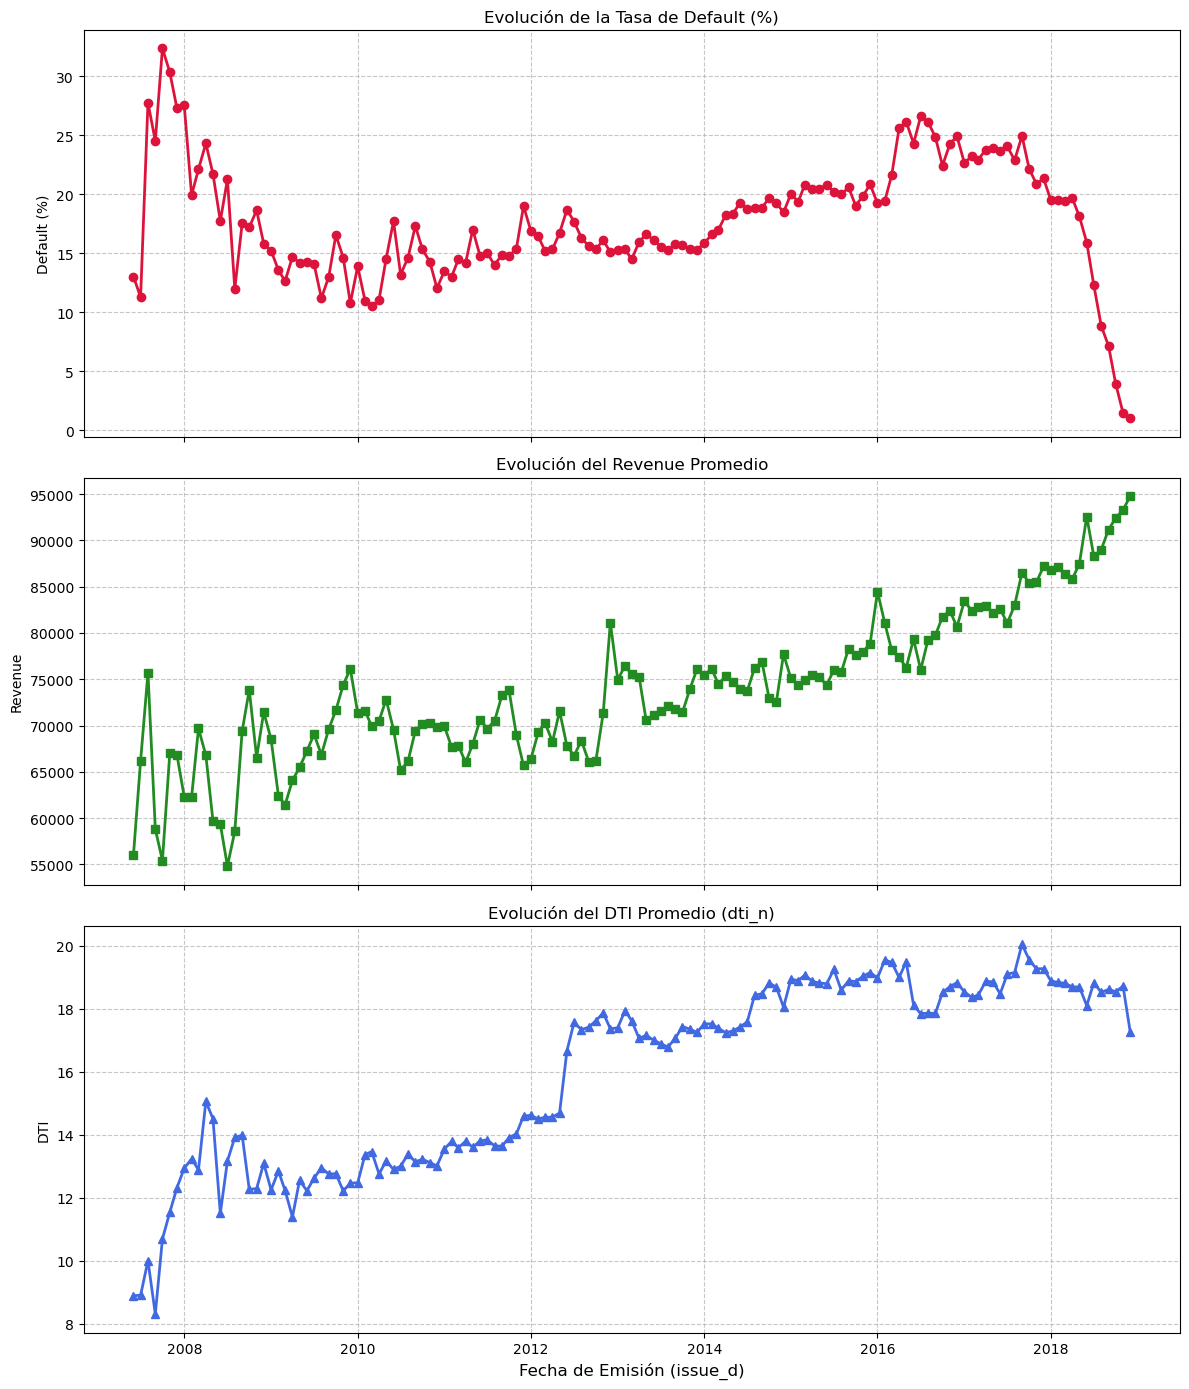

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# Por si acaso, nos aseguramos de que la fecha esté en el formato correcto
df['issue_d'] = pd.to_datetime(df['issue_d'])

# Creamos la "tabla de gráficos": 3 filas (nrows=3), 1 columna (ncols=1)
# sharex=True hace que solo el gráfico de abajo tenga las etiquetas de los meses, limpiando la vista
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 14), sharex=True)

# --- 1. Gráfico: Evolución del Default ---
tasa_default = df.groupby('issue_d')['Default'].mean() * 100
axes[0].plot(tasa_default.index, tasa_default.values, color='crimson', marker='o', linewidth=2)
axes[0].set_title('Evolución de la Tasa de Default (%)', fontsize=12)
axes[0].set_ylabel('Default (%)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- 2. Gráfico: Evolución del Revenue ---
# Nota: Usamos .mean() para ver el promedio mensual. Si prefieres ver el total sumado, usa .sum()
evolucion_revenue = df.groupby('issue_d')['revenue'].mean()
axes[1].plot(evolucion_revenue.index, evolucion_revenue.values, color='forestgreen', marker='s', linewidth=2)
axes[1].set_title('Evolución del Revenue Promedio', fontsize=12)
axes[1].set_ylabel('Revenue')
axes[1].grid(True, linestyle='--', alpha=0.7)

# --- 3. Gráfico: Evolución de dti_n ---
evolucion_dti = df.groupby('issue_d')['dti_n'].mean()
axes[2].plot(evolucion_dti.index, evolucion_dti.values, color='royalblue', marker='^', linewidth=2)
axes[2].set_title('Evolución del DTI Promedio (dti_n)', fontsize=12)
axes[2].set_ylabel('DTI')
axes[2].set_xlabel('Fecha de Emisión (issue_d)', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.7)

# Ajustamos automáticamente los espacios para que los títulos no choquen entre sí
plt.tight_layout()

# Mostramos el resultado
plt.show()